# **Generalized Bayes** : Linear Regression

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import arviz as az
import pymc as pm 
import pymc.math as pm_math
import seaborn as sns
import scipy 
from GeneralBayesFunctions import MHSample, cum_loss_L1, cum_loss_L2

## **I : Generalized Bayes :** dataset generation

We generate a linear dataset. Each datapoint following relation : 

$$ \forall k \in \set{1 \dots n},  y_k = \theta x_k + \epsilon_k , \epsilon_k \sim \mathcal{N}(0 ,\sigma^{2})$$



theta MLE : 0.8222467903219995
Theta : 0.75


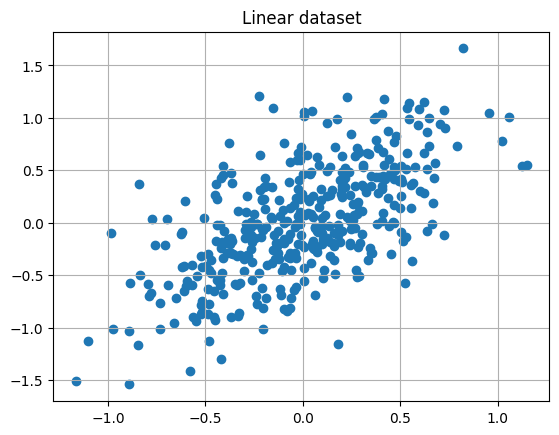

In [12]:
def generate_linear_data(X : np.array, coeff : float, sigma : float):
    n = X.shape[0]
    noise = np.random.normal(loc = 0, scale = sigma, size = n)
    return coeff*X + noise

def compute_mle(x : np.array , y : np.array):
    return (x.T)@y/np.sum(x**2)

sigma2 = 0.4
theta = 0.75

X = np.random.normal(loc = 0, scale = sigma2, size = 400)
Y = generate_linear_data(X, theta, sigma2)

fig, ax = plt.subplots()
ax.scatter(X, Y)
ax.set_title("Linear dataset")
ax.grid()

print(f"theta MLE : {compute_mle(X, Y)}")
print(f"Theta : 0.75")

## **II. Generalized Bayes** : prediction 

We suppose that $\theta$ is joint with a gaussian prior :  $\theta \sim \mathcal{N}(0, \tau^{2})$
Following the generalized bayes formula : 
$$q(\theta | y_{1:n}) \propto e^{-\eta L_n(\theta )} e^{-\frac{\theta^2}{2\tau^2}}$$
$$q(\theta | y_{1:n}) \propto e^{-\eta L_n(\theta ) - \frac{\theta^2}{2\tau^2}}$$



Sequential sampling (2 chains in 1 job)
Metropolis: [theta]


/home/perann/miniconda3/envs/dl_venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


R-hat: 1.0070476204189156
Effective sample size (ESS): 288.9978684909019


Text(0.5, 1.0, 'Markov chains genrerated')

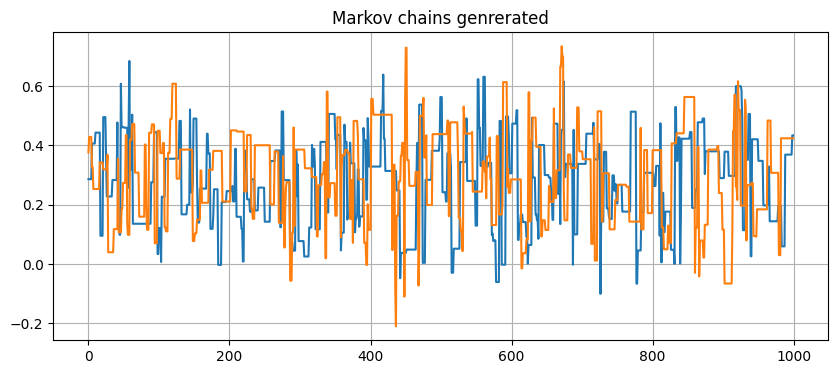

In [13]:
n_sample = 1000
tau = 0.2
eta = 0.1

samples = MHSample(n_sample, X,Y, tau, eta, cum_loss_L2)

chain_1 = samples.posterior.theta.values[0, : ]
chain_2 = samples.posterior.theta.values[1, : ]

fig, ax = plt.subplots(figsize = (10, 4))
ax.plot(chain_1)
ax.plot(chain_2)
ax.grid()
ax.set_title("Markov chains genrerated")

In classic bayesian framework, gaussian prior is conjugated for linear model : 

$\theta \mid y,X \sim \mathcal{N}(\mu_{\text{post}}, \Sigma_{\text{post}})$

With 

$\mu_{\text{post}} =
\left(
\frac{1}{\sigma^2} X^T X + \frac{1}{\tau^2} I
\right)^{-1}
\frac{1}{\sigma^2} X^T y$

$
\Sigma_{\text{post}} =
\left(
\frac{1}{\sigma^2} X^T X + \frac{1}{\tau^2} I
\right)^{-1}
$

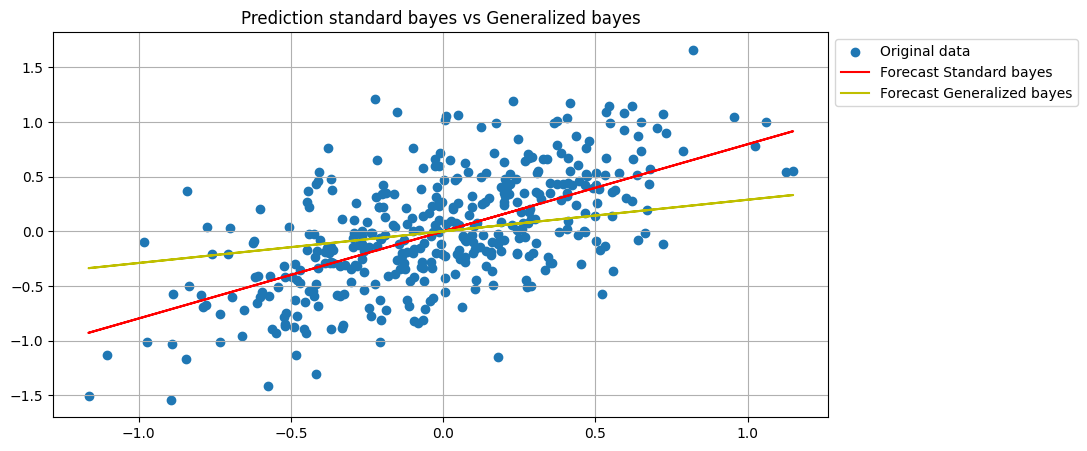

In [14]:
mu_post = (1/(X.T@X/sigma2 + 1/tau))*X.T@Y/sigma2

y_pred_sb = mu_post*X

mcmc_theta = np.mean(np.hstack([chain_1, chain_2]))
y_pred_gb = mcmc_theta*X

fig, ax = plt.subplots(figsize = (10, 5))
ax.scatter(X,Y, label = "Original data")
ax.plot(X, y_pred_sb, c = 'r', label = 'Forecast Standard bayes')
ax.plot(X, y_pred_gb, c = 'y', label = 'Forecast Generalized bayes')
ax.plot()
ax.grid()
ax.set_title("Prediction standard bayes vs Generalized bayes")
ax.legend(bbox_to_anchor =(1,1))

## **III. Generalized bayes** : parameter influence

### **A. Effect of $\eta$**

<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:19: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:19: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_520218/1044120576.py:16: SyntaxWarning: invalid escape sequence '\e'
  ax.plot(X, y_pred_gb, label = f'Generalized bayes $\eta$ : {eta}')
/tmp/ipykernel_520218/1044120576.py:19: SyntaxWarning: invalid escape sequence '\e'
  ax.set_title('$\eta$ impact on prediction')
Sequential sampling (2 chains in 1 job)
Metropolis: [theta]


/home/perann/miniconda3/envs/dl_venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
Sequential sampling (2 chains in 1 job)
Metropolis: [theta]


/home/perann/miniconda3/envs/dl_venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

R-hat: 1.010219491300765
Effective sample size (ESS): 299.9171126589818


...

/home/perann/miniconda3/envs/dl_venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

R-hat: 1.0027532563010366
Effective sample size (ESS): 408.6406135644225


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


R-hat: 1.0221085794182203
Effective sample size (ESS): 297.84465256982634


Text(0.5, 1.0, '$\\eta$ impact on prediction')

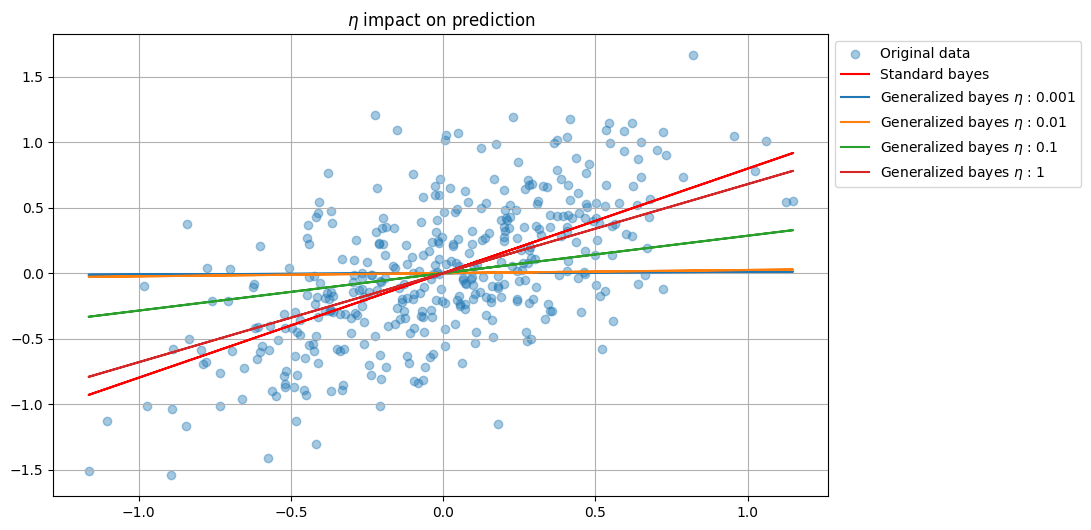

In [15]:
n_sample = 1000
tau = 0.2
etas = [0.001, 0.01, 0.1, 1]

fig, ax = plt.subplots(figsize = (10, 6))
ax.scatter(X,Y, alpha = 0.4, label = "Original data")
ax.plot(X, y_pred_sb, c = 'r', label = 'Standard bayes')
ax.grid()

for eta in etas:
    samples = MHSample(n_sample, X,Y, tau, eta, cum_loss_L2)
    chain_1 = samples.posterior.theta.values[0, : ]
    chain_2 = samples.posterior.theta.values[1, : ]
    mcmc_theta = np.mean(np.hstack([chain_1, chain_2]))
    y_pred_gb = mcmc_theta*X
    ax.plot(X, y_pred_gb, label = f'Generalized bayes $\eta$ : {eta}')

ax.legend(bbox_to_anchor = (1,1))
ax.set_title('$\eta$ impact on prediction')

Sequential sampling (2 chains in 1 job)
Metropolis: [theta]


/home/perann/miniconda3/envs/dl_venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


R-hat: 1.0018431105943801
Effective sample size (ESS): 521.4516374189684


Sequential sampling (2 chains in 1 job)
Metropolis: [theta]


...

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Sequential sampling (2 chains in 1 job)
Metropolis: [theta]


/home/perann/miniconda3/envs/dl_venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

R-hat: 1.0038985107330274
Effective sample size (ESS): 632.9035941855767


Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


R-hat: 1.0017049046193587
Effective sample size (ESS): 564.4805726616602


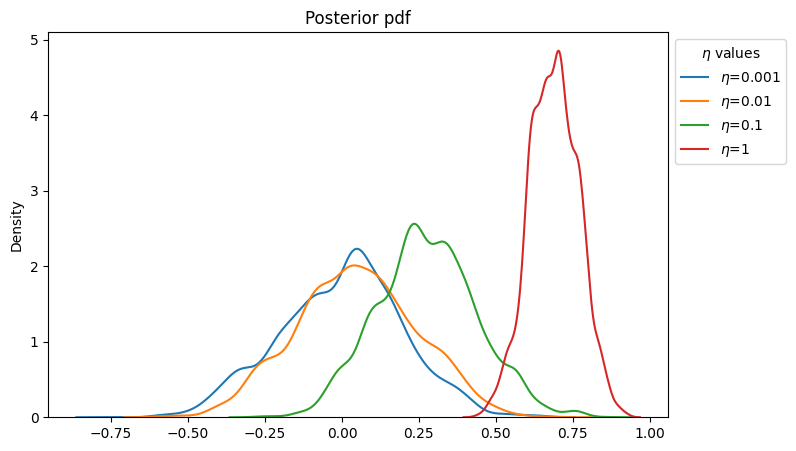

In [16]:
tau = 0.2
etas = [0.001, 0.01, 0.1, 1]
n_sample  = 2000
samples = []

for eta in etas:
    samples.append(MHSample(n_sample, X, Y, tau, eta, cum_loss_L2))


plt.figure(figsize=(8,5))

for i, eta in enumerate(etas):
    theta_samples = samples[i].posterior["theta"].values.flatten()
    sns.kdeplot(theta_samples, label=fr"$\eta$={eta}", fill=False)


plt.title("Posterior pdf")
plt.legend(title=fr"$\eta$ values", bbox_to_anchor=(1, 1))

### **B. Influence of $\tau$**

Sequential sampling (2 chains in 1 job)
Metropolis: [theta]


/home/perann/miniconda3/envs/dl_venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Sequential sampling (2 chains in 1 job)
Metropolis: [theta]


/home/perann/miniconda3/envs/dl_venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

R-hat: 1.0059559779275906
Effective sample size (ESS): 676.8861162049498


...

/home/perann/miniconda3/envs/dl_venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

R-hat: 1.0046449760087144
Effective sample size (ESS): 784.0426252343188


Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


R-hat: 1.006463934505864
Effective sample size (ESS): 699.216338684816


Text(0.5, 1.0, '$\\tau$ impact on prediction')

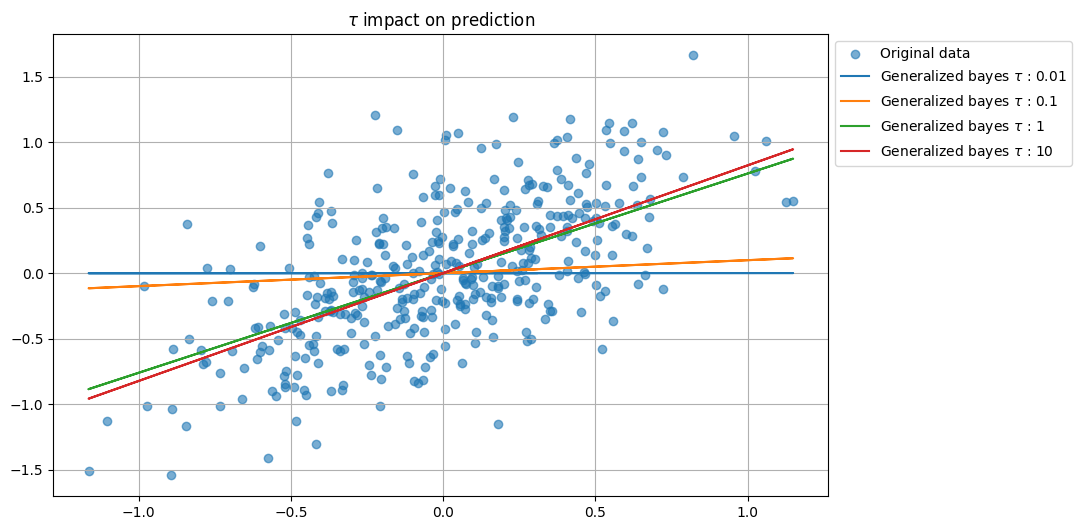

In [17]:
n_sample = 2000
taus = [0.01, 0.1,1, 10]
eta =  0.1

fig, ax = plt.subplots(figsize = (10, 6))
ax.scatter(X,Y, alpha = 0.6, label = "Original data")
ax.grid()

for tau in taus:
    samples = MHSample(n_sample, X,Y, tau, eta, cum_loss_L2)
    chain_1 = samples.posterior.theta.values[0, : ]
    chain_2 = samples.posterior.theta.values[1, : ]
    mcmc_theta = np.mean(np.hstack([chain_1, chain_2]))
    y_pred_gb = mcmc_theta*X
    ax.plot(X, y_pred_gb, label = fr'Generalized bayes $\tau$ : {tau}')

ax.legend(bbox_to_anchor = (1,1))
ax.set_title(r'$\tau$ impact on prediction')

Sequential sampling (2 chains in 1 job)
Metropolis: [theta]


/home/perann/miniconda3/envs/dl_venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


R-hat: 1.006112810620679
Effective sample size (ESS): 211.8753204833711


Sequential sampling (2 chains in 1 job)
Metropolis: [theta]


...

Sequential sampling (2 chains in 1 job)
Metropolis: [theta]


/home/perann/miniconda3/envs/dl_venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


R-hat: 1.0018326594280085
Effective sample size (ESS): 355.75329001271905


Text(0.5, 1.0, '$\\tau$ impact on pdf')

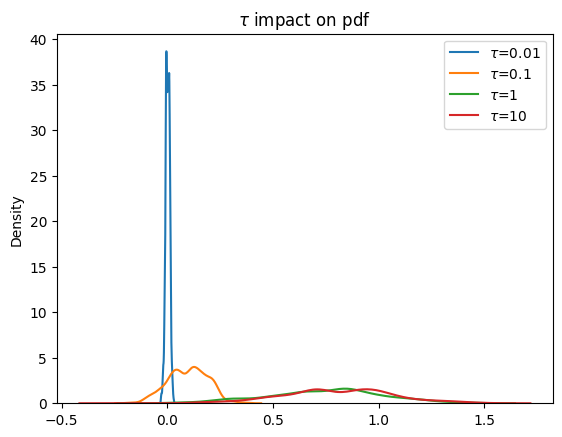

In [20]:
n_sample = 1000
taus = [0.01, 0.1,1, 10]
eta =  0.1


for tau in taus:
    samples = MHSample(n_sample, X,Y, tau, eta, cum_loss_L2)
    chain_1 = samples.posterior.theta.values[0, : ]
    chain_2 = samples.posterior.theta.values[1, : ]
    mcmc_theta = np.hstack([chain_1, chain_2])
    sns.kdeplot(mcmc_theta, label=fr"$\tau$={tau}", fill=False)


plt.legend(bbox_to_anchor = (1,1))
plt.title(fr'$\tau$ impact on pdf')

### **C. Loss influence** 

Sequential sampling (2 chains in 1 job)
Metropolis: [theta]


/home/perann/miniconda3/envs/dl_venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 3_000 draw iterations (2_000 + 6_000 draws total) took 2 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
Sequential sampling (2 chains in 1 job)
Metropolis: [theta]


/home/perann/miniconda3/envs/dl_venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

R-hat: 1.000533405320965
Effective sample size (ESS): 897.4636634204155


Sampling 2 chains for 1_000 tune and 3_000 draw iterations (2_000 + 6_000 draws total) took 2 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


R-hat: 1.004150373795386
Effective sample size (ESS): 922.6338497143215


Text(0.5, 1.0, 'Loss impact on prediction')

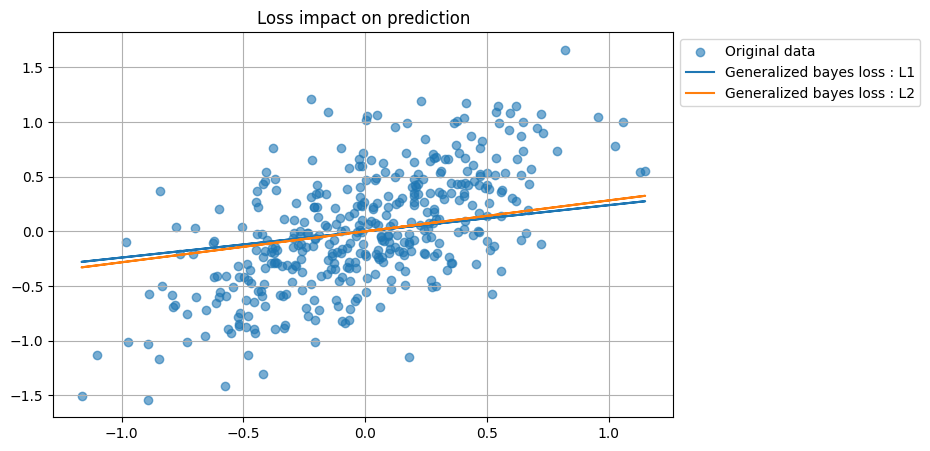

In [21]:
n_sample = 3000
tau = 0.2
eta =  0.1
losses = {"L1" : cum_loss_L1, "L2" :cum_loss_L2}

fig, ax = plt.subplots(figsize = (8, 5))
ax.scatter(X,Y, alpha = 0.6, label = "Original data")
ax.grid()


for loss in losses:
    samples = MHSample(n_sample, X,Y, tau, eta, losses[loss])
    chain_1 = samples.posterior.theta.values[0, : ]
    chain_2 = samples.posterior.theta.values[1, : ]
    mcmc_theta = np.mean(np.hstack([chain_1, chain_2]))
    y_pred_gb = mcmc_theta*X
    ax.plot(X, y_pred_gb, label = f'Generalized bayes loss : {loss}')

ax.legend(bbox_to_anchor = (1,1))
ax.set_title('Loss impact on prediction')


Sequential sampling (2 chains in 1 job)
Metropolis: [theta]


/home/perann/miniconda3/envs/dl_venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 3_000 draw iterations (2_000 + 6_000 draws total) took 2 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


R-hat: 1.004547348606768
Effective sample size (ESS): 994.4804080364845


Sequential sampling (2 chains in 1 job)
Metropolis: [theta]


/home/perann/miniconda3/envs/dl_venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 3_000 draw iterations (2_000 + 6_000 draws total) took 2 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


R-hat: 1.0037002522197935
Effective sample size (ESS): 992.17716828554


Text(0.5, 1.0, 'Loss impact on pdf')

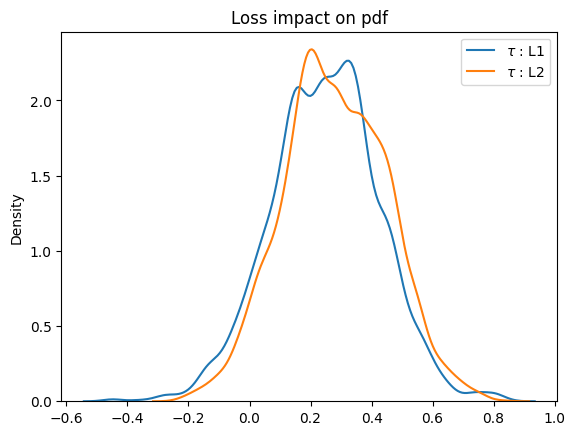

In [22]:
for loss in losses:
    samples = MHSample(n_sample, X,Y, tau, eta, losses[loss])
    chain_1 = samples.posterior.theta.values[0, : ]
    chain_2 = samples.posterior.theta.values[1, : ]
    mcmc_theta = np.hstack([chain_1, chain_2])
    sns.kdeplot(mcmc_theta, label=fr"$\tau$ : {loss}", fill=False)

plt.legend(bbox_to_anchor = (1,1))
plt.title('Loss impact on pdf')

## **IV. General Bayes** : Bayes factor

Sequential sampling (2 chains in 1 job)
Metropolis: [theta]


/home/perann/miniconda3/envs/dl_venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 5_000 draw iterations (2_000 + 10_000 draws total) took 3 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


R-hat: 1.001239372970655
Effective sample size (ESS): 1994.2896629098043


Sequential sampling (2 chains in 1 job)
Metropolis: [theta]


/home/perann/miniconda3/envs/dl_venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 5_000 draw iterations (2_000 + 10_000 draws total) took 3 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


R-hat: 1.0004011411873581
Effective sample size (ESS): 1972.3527193896155


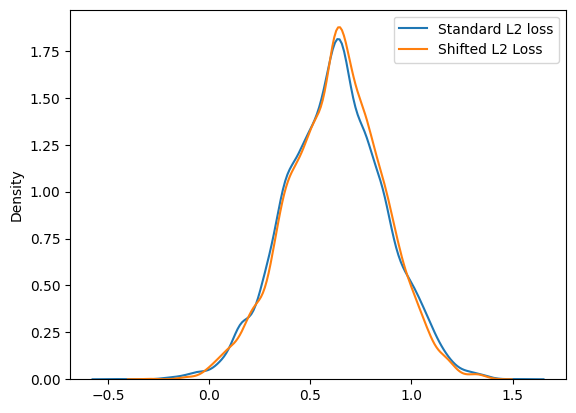

In [32]:
def cum_loss_L2_with_shift(x, y, theta):
    shift = np.sum(y**2) 
    return cum_loss_L2(x, y, theta) + shift


tau = 0.5
eta = 0.1
n_samples = 5000

theta_standard = MHSample(n_samples, X, Y, tau, eta, cum_loss_L2)
ch_1 = theta_standard.posterior.theta.values[0, : ]
ch_2 = theta_standard.posterior.theta.values[1, : ]
thetas_sampled_standard = np.hstack([ch_1, ch_2])

theta_shift = MHSample(n_samples, X, Y, tau, eta, cum_loss_L2_with_shift)
ch_1 = theta_shift.posterior.theta.values[0, : ]
ch_2 = theta_shift.posterior.theta.values[1, : ]
thetas_sampled_shift= np.hstack([ch_1, ch_2])

sns.kdeplot(thetas_sampled_standard, label=f"Standard L2 loss", fill=False)
sns.kdeplot(thetas_sampled_shift, label=f"Shifted L2 Loss", fill=False)
plt.legend(bbox_to_anchor = (1,1))

In [ ]:
def cum_loss_L2(x, y, theta):

    if np.ndim(theta) == 0:
        theta = np.array([theta])
        
    diff = y[:, np.newaxis] - (x[:, np.newaxis] * theta[np.newaxis, :])
    result = np.sum(diff**2, axis=0)
    
    return result[0] if result.size == 1 else result

def estimate_log_Z(thetas, X, Y, eta, loss_func, tau):    
    log_potentials = []
    for t in thetas:
        l = loss_func(X, Y, t)
        
        log_prior = -0.5 * (t / tau)**2 - 0.5 * np.log(2 * np.pi * tau**2)
        log_potentials.append(-eta * l + log_prior)
    
    return scipy.special.logsumexp(log_potentials) - np.log(len(thetas))

log_z1 = estimate_log_Z(thetas_sampled_standard, X, Y, eta, cum_loss_L2, tau)
log_z2 = estimate_log_Z(thetas_sampled_shift, X, Y, eta, cum_loss_L2_with_shift, tau)

print(f"Log Z (Standard) : {log_z1:.4f}")
print(f"Log Z (Shifted)   : {log_z2:.4f}")

Log Z (Standard) : -8.6210
Log Z (Shifted)   : -20.0354


## **V. General Bayes** : Miss specified model

We miss specify the model by supposing the following relation $y = e^{\theta x}$. 

Sequential sampling (2 chains in 1 job)
Metropolis: [theta]


/home/perann/miniconda3/envs/dl_venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


R-hat: 1.0315403087311141
Effective sample size (ESS): 244.28824217186343


Text(0.5, 1.0, 'Generated chain')

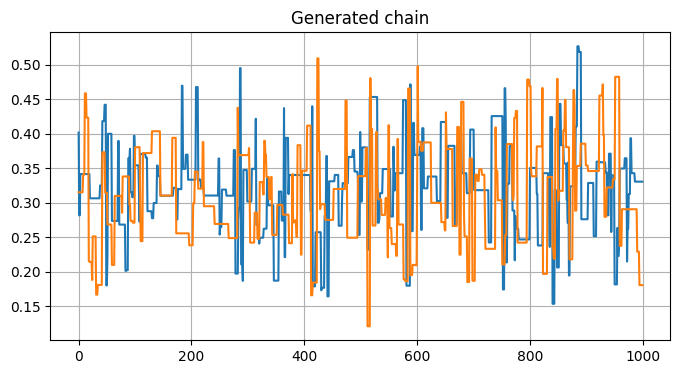

In [53]:
def cum_loss_L2_exp(x, y, theta):
    return pm_math.sum((y - np.exp(x*theta))**2)


n_sample = 1000
tau= 0.2
eta =  0.1


samples = MHSample(n_sample, X,Y, tau, eta, cum_loss_L2_exp)
chain_1 = samples.posterior.theta.values[0, : ]
chain_2 = samples.posterior.theta.values[1, : ]

fig, ax = plt.subplots(figsize = (8,4))
ax.plot(chain_1)
ax.plot(chain_2)
ax.grid()
ax.set_title("Generated chain")

To build a predictor, we use the following monte carlo approximation of the conditional expected value:

$$\mathbb{E}[e^{X\theta} | X = x] \approx \frac{1}{N}\sum_{i=1}^{N} e^{x\theta_i}, \theta_i \sim q(\theta | y_{1: n})$$

<>:25: SyntaxWarning: invalid escape sequence '\e'
<>:29: SyntaxWarning: invalid escape sequence '\e'
<>:25: SyntaxWarning: invalid escape sequence '\e'
<>:29: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_513069/3003661451.py:25: SyntaxWarning: invalid escape sequence '\e'
  ax.plot(x_linspace,y_pred_gb, label = f"Generalized bayes for $\eta$ : {eta}")
/tmp/ipykernel_513069/3003661451.py:29: SyntaxWarning: invalid escape sequence '\e'
  ax.set_title("Miss specified model, $\eta$ value comparison")
Sequential sampling (2 chains in 1 job)
Metropolis: [theta]


/home/perann/miniconda3/envs/dl_venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


R-hat: 1.0168533104734574
Effective sample size (ESS): 279.98435532857064


Sequential sampling (2 chains in 1 job)
Metropolis: [theta]


...

/home/perann/miniconda3/envs/dl_venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

R-hat: 1.0099708284768738
Effective sample size (ESS): 253.92859473006737


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


R-hat: 1.0024520659769314
Effective sample size (ESS): 300.5200823907385


Text(0.5, 1.0, 'Miss specified model, $\\eta$ value comparison')

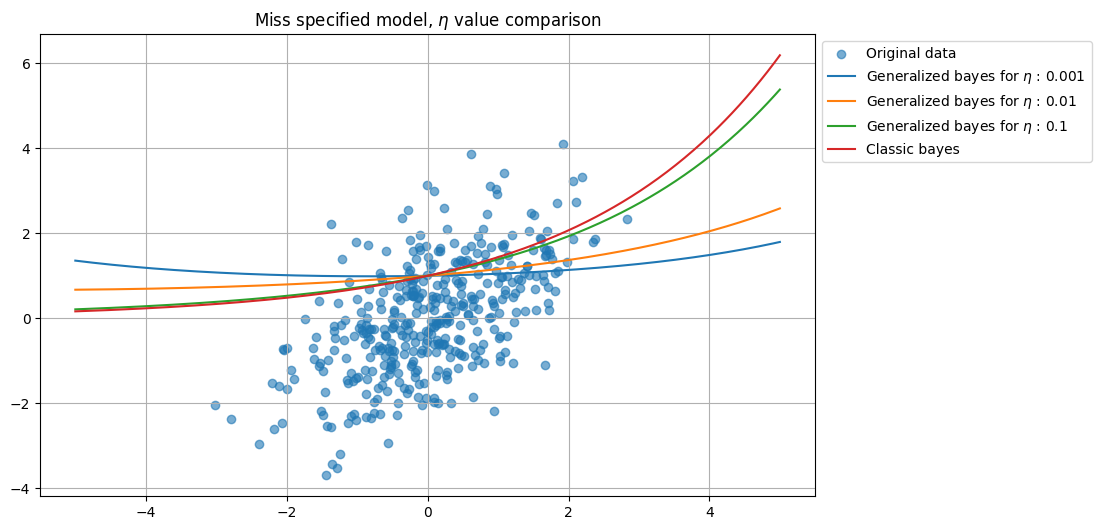

In [43]:
def y_predictor(x : float, thetas : np.array):
    N = thetas.shape[0]
    return np.sum(np.exp(x*thetas))/N


n_sample = 1000
tau = 0.2
etas = [0.001, 0.01, 0.1, 1]
x_linspace = np.linspace(-5, 5, 400)

fig ,ax = plt.subplots(figsize = (10, 6))
ax.scatter(X,Y, alpha = 0.6, label = "Original data")

for eta in etas:
    samples = MHSample(n_sample, X,Y, tau, eta, cum_loss_L2_exp)
    chain_1 = samples.posterior.theta.values[0, : ]
    chain_2 = samples.posterior.theta.values[1, : ]
    thetas = np.hstack([chain_1, chain_2])
    y_pred_gb = [y_predictor(k, thetas) for k in x_linspace]

    if eta == 1 :
        ax.plot(x_linspace,y_pred_gb, label = f"Classic bayes")
        continue

    ax.plot(x_linspace,y_pred_gb, label = f"Generalized bayes for $\eta$ : {eta}")

ax.grid()
ax.legend(bbox_to_anchor =(1,1))
ax.set_title("Miss specified model, $\eta$ value comparison")